<a href="https://colab.research.google.com/github/Nobodybutyouu/FBD_detection_models/blob/main/FBD_detection_Inception_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
#Step 2

import os
import numpy as np
import matplotlib.pyplot as plt
import itertools

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Dense, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import confusion_matrix, classification_report


In [14]:
#Step 3

!cp -r "/content/drive/MyDrive/ricePlant_dataSet" "/content/"

train_dir = "/content/drive/MyDrive/ricePlant_dataSet/train"
test_dir  = "/content/drive/MyDrive/ricePlant_dataSet/test"

print("Dataset copied to local runtime")

Dataset copied to local runtime


In [15]:
IMG_SIZE = 299
BATCH_SIZE = 32
EPOCHS = 50

train_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

num_classes = train_generator.num_classes
class_names = list(train_generator.class_indices.keys())
print("Classes:", class_names)

Found 800 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
Classes: ['Healthy_images', 'Unhealthy_images']


In [16]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

In [17]:
base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(299,299,3)
)

base_model.trainable = False   # Freeze base layers

In [18]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, 149, 149,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 149, 149,  │         96 │ conv2d_94[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_94       │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 147, 147,  │      9,216 │ activation_94[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_95[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_95       │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 147, 147,  │     18,432 │ activation_95[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_96[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_96       │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 73, 73,    │          0 │ activation_96[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, 73, 73,    │      5,120 │ max_pooling2d_4[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_97[0][0]   │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_97       │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_98 (Conv2D)  │ (None, 71, 71,    │    138,240 │ activation_97[0]… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_98[0][0]   │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_98       │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 22,983,714 (87.68 MB)

 Trainable params: 1,180,930 (4.50 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [19]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 285s 11s/step - accuracy: 0.5234 - loss: 1.1064 - val_accuracy: 0.6050 - val_loss: 0.6472
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 270s 11s/step - accuracy: 0.6218 - loss: 0.7325 - val_accuracy: 0.6450 - val_loss: 0.6618
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 318s 11s/step - accuracy: 0.6891 - loss: 0.6191 - val_accuracy: 0.6700 - val_loss: 0.5934
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 272s 11s/step - accuracy: 0.7434 - loss: 0.5380 - val_accuracy: 0.7400 - val_loss: 0.5769
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 267s 11s/step - accuracy: 0.7272 - loss: 0.5501 - val_accuracy: 0.7350 - val_loss: 0.5192
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 267s 11s/step - accuracy: 0.7514 - loss: 0.4851 - val_accuracy: 0.7350 - val_loss: 0.5236
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 301s 12s/step - accuracy: 0.8132 - loss: 0.4249 - val_accuracy: 0.7200 - val_loss: 0.5196
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 268s 11s/step - accuracy: 0.7642 - loss: 0.4736 - val_accuracy: 0.

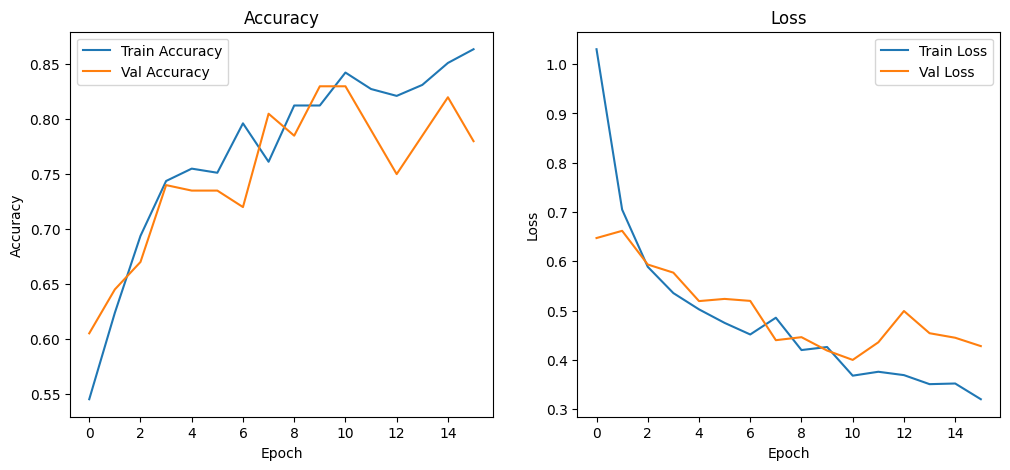

In [20]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [21]:
y_true = test_generator.classes

y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_true, y_pred)



7/7 ━━━━━━━━━━━━━━━━━━━━ 57s 7s/step


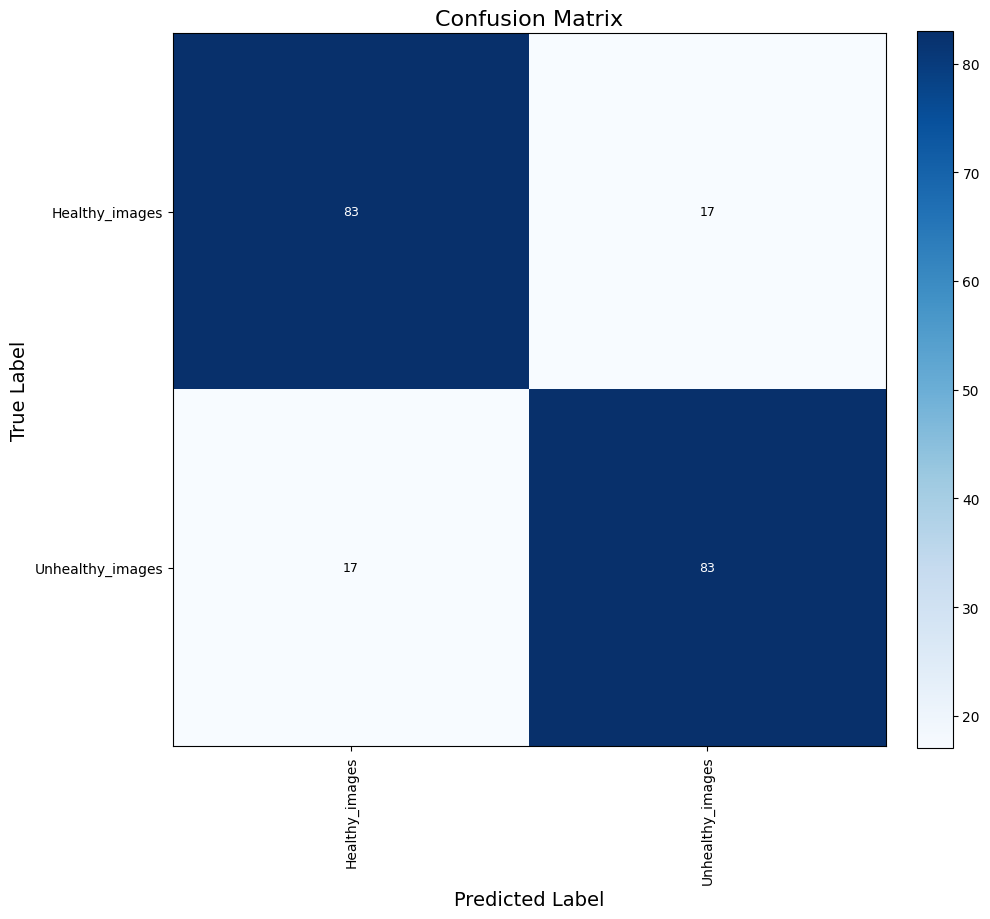

Classification Report:

                  precision    recall  f1-score   support

  Healthy_images     0.8300    0.8300    0.8300       100
Unhealthy_images     0.8300    0.8300    0.8300       100

        accuracy                         0.8300       200
       macro avg     0.8300    0.8300    0.8300       200
    weighted avg     0.8300    0.8300    0.8300       200



In [22]:
def plot_confusion_matrix(cm, class_names):
    num_classes = len(class_names)

    fig_size = max(10, num_classes * 0.7)
    plt.figure(figsize=(fig_size, fig_size))

    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title("Confusion Matrix", fontsize=16)
    plt.colorbar(fraction=0.046, pad=0.04)

    tick_marks = np.arange(num_classes)
    plt.xticks(tick_marks, class_names, rotation=90, fontsize=10)
    plt.yticks(tick_marks, class_names, fontsize=10)

    thresh = cm.max() / 2
    for i in range(num_classes):
        for j in range(num_classes):
            plt.text(
                j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                fontsize=9,
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.ylabel('True Label', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(cm, class_names)

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("Classification Report:\n")
print(report)
